# **Data Preparation:**

In [1]:
import numpy as np
import pandas as pd 
import math 
import warnings

In [2]:
warnings.filterwarnings(action= "ignore")

In [13]:
data_train= pd.read_csv("train.csv", sep= ";")
data_train.shape

(45211, 17)

In [14]:
data_train.head(3)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no


In [15]:
data_test= pd.read_csv("test.csv", sep= ";")

In [23]:
data_test.head(3)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no


Now, we stack the two dataframes vertically:

In [ ]:
# Stack both the dataframes vertically: 
#data= pd.concat([data_train, data_test], axis= 0)
#data.shape

(49732, 17)

But the test dataset is obtained by randomly taking values from the train.csv dataset so, we need no stacking of datasets. Stacking these two datasets instead creates duplicate entries.

In [26]:
data= data_train

In [27]:
data.head(3)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no


In [28]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [29]:
data.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

`Term deposits` are a major source of income for a bank. A term deposit is a cash investment held at a financial institution. Our money is invested for an agreed rate of interest over a fixed amount of time, or term. 

The bank has various outreach plans to sell term deposits to their customers such as `email marketing,` `advertisements`, `telephonic marketing`, and `digital marketing`.

Telephonic marketing campaigns still remain one of the most effective way to reach out to people. However, they require huge investment as large call centers are hired to actually execute these campaigns. Hence, it is crucial to identify the customers most likely to convert beforehand so that they can be specifically targeted via call.

The data is related to `direct marketing campaigns (phone calls)` of a Portuguese banking institution. *`The classification goal is to predict if the client will subscribe to a term deposit (variable y).`*

1. - `age` (numeric)

2. - `job` : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
"blue-collar","self-employed","retired","technician","services")

3. - `marital` : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)

4. - `education` (categorical: "unknown","secondary","primary","tertiary")

5. - `default`: has credit in default? (binary: "yes","no")

6. - `balance`: average yearly balance, in euros (numeric)

7. - `housing`: has housing loan? (binary: "yes","no")

8. - `loan`: has personal loan? (binary: "yes","no")

**Related with the last contact of the current campaign:**  

9. - `contact`: contact communication type (categorical: "unknown","telephone","cellular")

10. - `day`: last contact day of the month (numeric)

11. - `month`: last contact month of year (categorical: "jan", "feb", "mar", …, "nov", "dec")

12. - `duration`: last contact duration, in seconds (numeric)

**Other Attributes:**

13. - `campaign`: number of contacts performed during this campaign and for this client (numeric, includes last contact)

14. - `pdays`: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)

15. - `previous`: number of contacts performed before this campaign and for this client (numeric)

16. - `poutcome`: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

**Output Variable (desired target):**  

17. - `y` - has the client subscribed a term deposit? (binary: "yes","no")

In [30]:
data.duplicated().sum()

np.int64(0)

In [31]:
# check if we can give a better data type to columns: 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [32]:
data.head(2)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no


Everything seems all right and we do nothing for now. 

In [34]:
# Checking for missing values: 
data.isna().sum().any()

np.False_

In [38]:
# calculate general statistics of numeric features: 
data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [41]:
# Correlation of numeric variables: 
corr= data.select_dtypes(include= "int64").corr(method= "spearman")
corr

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.096380,-0.008948,-0.033257,0.037136,-0.017468,-0.011900
balance,0.096380,1.000000,0.001329,0.042651,-0.030959,0.069676,0.079536
day,-0.008948,0.001329,1.000000,-0.058142,0.139581,-0.092226,-0.087780
duration,-0.033257,0.042651,-0.058142,1.000000,-0.107962,0.028698,0.031175
campaign,0.037136,-0.030959,0.139581,-0.107962,1.000000,-0.112284,-0.108448
pdays,-0.017468,0.069676,-0.092226,0.028698,-0.112284,1.000000,0.985645
previous,-0.011900,0.079536,-0.087780,0.031175,-0.108448,0.985645,1.000000


<Axes: >

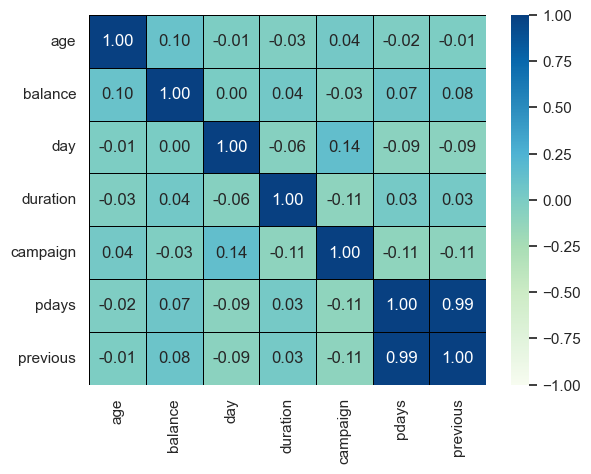

In [55]:
import seaborn as sns 
sns.set_theme(context= "notebook", style= "darkgrid", palette= "deep")
sns.heatmap(data= corr, annot= True, cmap= "GnBu", linewidths= 0.5, linecolor= "black", vmin= -1, vmax= 1, fmt= ".2f")

`pdays` ans `previous` are highly correlated and apart from this, no any other features seems to have significant correlation. 